# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Muhammad Nazwar Fakhrurrozy | 5054251040|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score,roc_curve,)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, CategoricalNB, MultinomialNB
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [54]:
# Load dataset dan tampilkan beberapa baris pertama.
df = pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [55]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
print(f"Bentuk Dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")

print('Tipe Data dan Missing Values')
df.info()

missing_stalk = (df['stalk-root'] == '?').sum()
print(f'\nJumlah missing value ? pada kolom stalk-root: {missing_stalk} ({missing_stalk / len(df) * 100:.2f}%)')

Bentuk Dataset: 8124 baris, 23 kolom

Tipe Data dan Missing Values
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-nu

In [56]:
# Tampilkan jumlah nilai unik pada setiap fitur.
unique_counts = df.nunique()
print('jumlah nilai unik per fitur')
print(unique_counts)

single_val = unique_counts[unique_counts == 1].index.tolist()
print(f'\nyang hanya punya 1 nilai unik: {single_val}')

jumlah nilai unik per fitur
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

yang hanya punya 1 nilai unik: ['veil-type']


Edible (e)    : 4208 (51.80%)
Poisonous (p) : 3916 (48.20%)


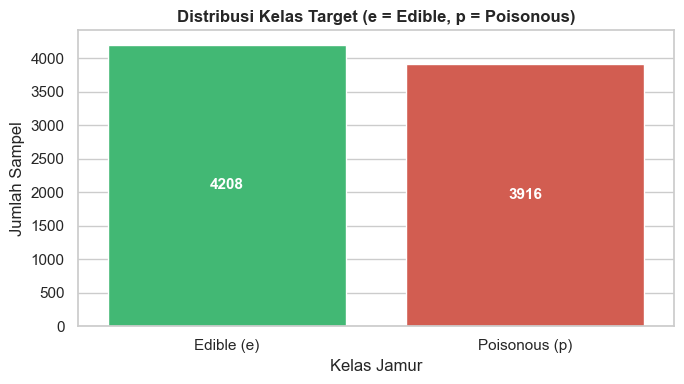

In [57]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

print(f"Edible (e)    : {class_counts['e']} ({class_pct['e']:.2f}%)")
print(f"Poisonous (p) : {class_counts['p']} ({class_pct['p']:.2f}%)")

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    hue=class_counts.index, 
    palette=['#2ecc71', '#e74c3c'], 
    legend=False
)
plt.title('Distribusi Kelas Target (e = Edible, p = Poisonous)', fontsize=12, fontweight='bold')
plt.xlabel('Kelas Jamur')
plt.ylabel('Jumlah Sampel')
plt.xticks([0, 1], ['Edible (e)', 'Poisonous (p)'])

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

bisa dilihat disini datasetnya sudah balanced, tidak perlu resampling dan semacamnya, train test split sudah cukup digunakan nnti

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [58]:
# Tangani missing value pada kolom stalk-root (nilai '?').
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')
print(f'Nilai unik pada stalk-root setelah cleaned: {df["stalk-root"].unique()}')

Nilai unik pada stalk-root setelah cleaned: <ArrowStringArray>
['e', 'c', 'b', 'r', 'missing']
Length: 5, dtype: str


In [59]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Fitur yang akan di drop (1 nilai unik): {single_val_cols}')

df_clean = df.drop(columns=single_val_cols)
print(f'Sisa fitur setelah di drop: {df_clean.shape[1] - 1} fitur predictor')

Fitur yang akan di drop (1 nilai unik): ['veil-type']
Sisa fitur setelah di drop: 21 fitur predictor


In [60]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop(columns=['class'])
y = df_clean['class'].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape[0]} baris, Test set: {X_test.shape[0]} baris')
print(f'Distribusi y_train:\n{y_train.value_counts(normalize=True)}')

Train set: 6499 baris, Test set: 1625 baris
Distribusi y_train:
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64


In [61]:
# Preprocessing untuk Categorical NB:
encoder_cat = OrdinalEncoder()

X_train_cat = encoder_cat.fit_transform(X_train)
X_test_cat = encoder_cat.transform(X_test)

print(f'Bentuk data Categorical NB (Train): {X_train_cat.shape}')
print(f'Bentuk data Categorical NB (Test) : {X_test_cat.shape}')

Bentuk data Categorical NB (Train): (6499, 21)
Bentuk data Categorical NB (Test) : (1625, 21)


In [62]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
encoder_ohe = OneHotEncoder(sparse_output=False)

X_train_ohe = encoder_ohe.fit_transform(X_train)
X_test_ohe = encoder_ohe.transform(X_test)

print(f'Bentuk data One-Hot Encoded (Train): {X_train_ohe.shape}')
print(f'Bentuk data One-Hot Encoded (Test) : {X_test_ohe.shape}')

Bentuk data One-Hot Encoded (Train): (6499, 116)
Bentuk data One-Hot Encoded (Test) : (1625, 116)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [63]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cat_nb = CategoricalNB()
cat_nb.fit(X_train_cat, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [64]:
# Lakukan prediksi pada test set.
y_pred_cat = cat_nb.predict(X_test_cat)
y_prob_cat = cat_nb.predict_proba(X_test_cat)[:, 1]

print(f'prediksi selesai pada {len(y_pred_cat)} sampel data uji.')

prediksi selesai pada 1625 sampel data uji.


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [65]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
ber_nb = BernoulliNB()
ber_nb.fit(X_train_ohe, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [66]:
# Lakukan prediksi pada test set.
y_pred_ber = ber_nb.predict(X_test_ohe)
y_prob_ber = ber_nb.predict_proba(X_test_ohe)[:, 1]

print(f'prediksi selesai pada {len(y_pred_ber)} sampel data uji.')


prediksi selesai pada 1625 sampel data uji.


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [67]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
mul_nb = MultinomialNB()
mul_nb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [68]:
# Lakukan prediksi pada test set.
y_pred_mul = mul_nb.predict(X_test_ohe)
y_prob_mul = mul_nb.predict_proba(X_test_ohe)[:, 1]

print(f'prediksi selesai pada {len(y_pred_mul)} sampel data uji.')

prediksi selesai pada 1625 sampel data uji.


# 4. Evaluasi Model

In [69]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
models = [
    ('Categorical NB', y_pred_cat),
    ('Bernoulli NB', y_pred_ber),
    ('Multinomial NB', y_pred_mul)
]
metrics = []
for name, y_pred in models:
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


categorical dan multinomial performa nya mirip paling bagus juga, akurasinya tembus 94.58% dengan presisi 99.01%, kalau bernoulli beda 7% dibawah mereka 

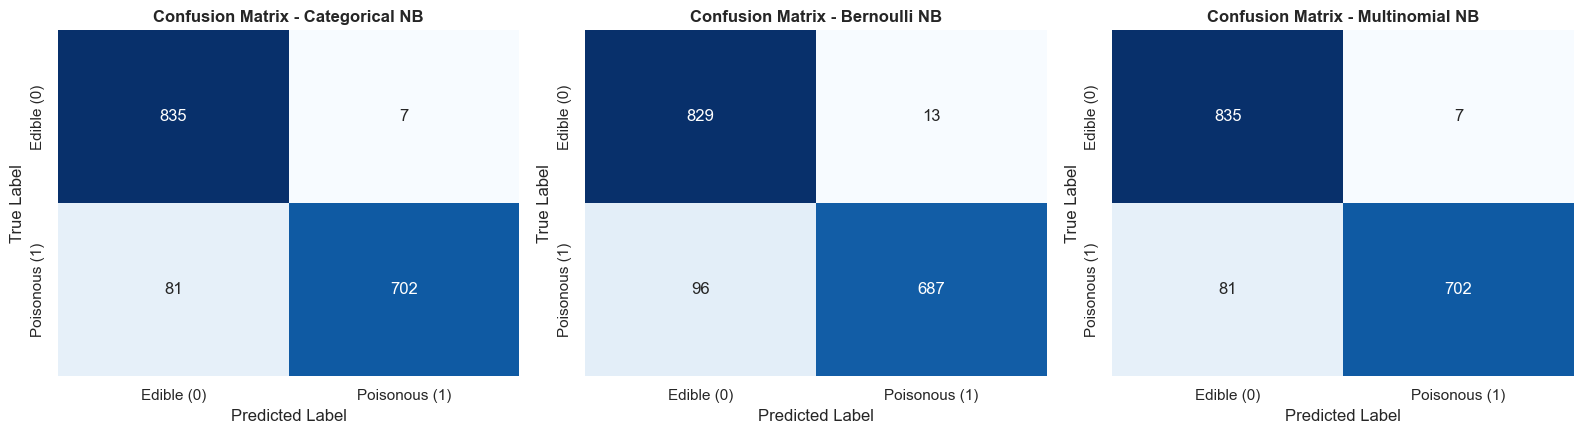

In [70]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm_data = [
    ('Categorical NB', confusion_matrix(y_test, y_pred_cat)),
    ('Bernoulli NB', confusion_matrix(y_test, y_pred_ber)),
    ('Multinomial NB', confusion_matrix(y_test, y_pred_mul))
]
for ax, (title, cm) in zip(axes, cm_data):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Edible (0)', 'Poisonous (1)'],
                yticklabels=['Edible (0)', 'Poisonous (1)'])
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

seperti skor sebelumnya  categorical multinomial Cuma bikin kesalahan kecil 7 sampel jamur False Positive dan 81 jamur False Negative, sedangkan bernoulli lumayan banyak kecolongan jamur poisonous

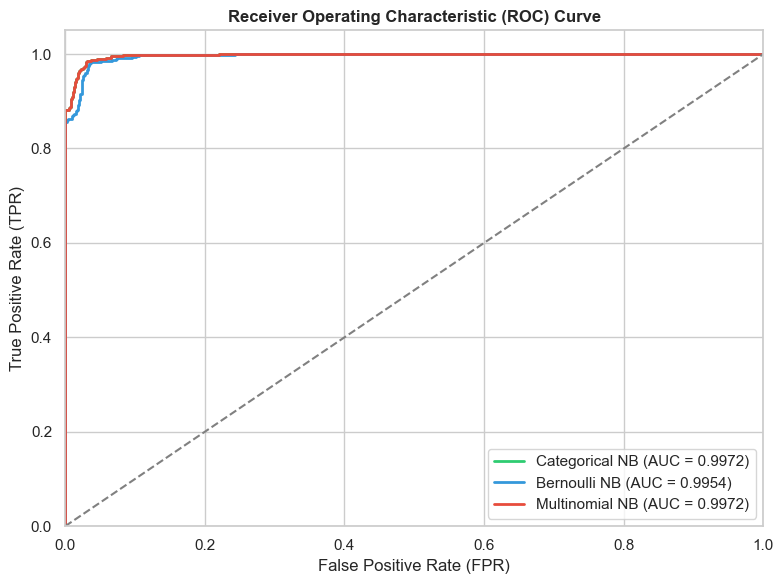

In [71]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(8, 6))

roc_data = [
    ('Categorical NB', y_prob_cat, '#2ecc71'),
    ('Bernoulli NB', y_prob_ber, '#3498db'),
    ('Multinomial NB', y_prob_mul, '#e74c3c')
]

for name, y_prob, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

kurva ketiga model kelihatan hampir nempel sempurna di pojok kiri atas, berarti kemampuan membedakan kelas jamur sudah sangat bagus.

# 5. Analisis

Berdasarkan hasil eksperimen klasifikasi jamur menggunakan 1.625 sampel data uji, model Categorical NB dan Multinomial NB mencatatkan kinerja terbaik yang identik dengan nilai Accuracy 94.58%, Precision 99.01%, Recall 89.66%, F1-Score 94.10%, serta nilai AUC 0.9972. Sementara itu, Bernoulli NB menghasilkan kinerja sedikit di bawah keduanya dengan Accuracy 93.29%, Precision 98.14%, Recall 87.74%, F1-Score 92.65%, dan AUC 0.9954

Perbedaan performa ketiga varian Naive Bayes ini berkaitan erat dengan cara masing-masing model merepresentasikannya secara matematis:

1. Categorical NB dan Multinomial NB (Performa Identik 94.58%)
Categorical NB bekerja pada matriks integer hasil OrdinalEncoder dengan mengestimasi probabilitas P(fitur = kategori | kelas) secara langsung untuk tiap kategori. Di sisi lain, Multinomial NB yang menerima matriks biner 0/1 hasil OneHotEncoder menginterpretasikan angka 1 sebagai frekuensi kemunculan fitur (count). Dalam konteks variabel biner terpisah, perhitungan estimasi parameter Multinomial NB menghasilkan bobot log-likelihood yang setara dengan Categorical NB, sehingga menghasilkan keputusan klasifikasi dan confusion matrix yang persis sama (835 True Negative, 702 True Positive, 7 False Positive, dan 81 False Negative)

2. Bernoulli NB (Performa 93.29%)
Bernoulli NB mengevaluasi keberadaan (presence) dan ketidakberadaan (absence) setiap fitur biner melalui suku P(fitur = 1 | kelas) dan P(fitur = 0 | kelas). Karena OneHotEncoder menghasilkan 116 kolom fitur yang didominasi nilai 0 (sparse matrix), perkalian probabilitas dari fitur-fitur yang bernilai 0 menambahkan penalti berlebih pada perhitungan posterior. Hal ini menyebabkan Bernoulli NB mengalami penurunan Recall (terdapat 96 sampel False Negative di mana jamur beracun terprediksi aman dimakan)

# 6. Kesimpulan dan Saran

Kesimpulan:
1. Categorical NB dan Multinomial NB merupakan varian terbaik untuk klasifikasi jamur pada eksperimen ini dengan akurasi 94.58% dan Presisi 99.01%
2. Representasi data bertipe kategorikal terbukti paling selaras dengan asumsi dasar Categorical NB (via OrdinalEncoder) dan Multinomial NB (via OneHotEncoder)
3. Bernoulli NB kurang optimal pada matriks biner yang berdimensi banyak (sparse) karena memperhitungkan ketidakberadaan fitur (nilai 0) yang menambah noise pada kalkulasi probabilitas

Saran:
1. Mengeliminasi fitur dengan korelasi rendah atau mengisolasi fitur prediktif utama seperti odor (bau jamur) untuk meningkatkan Recall hingga mendekati 100% demi keamanan konsumsi jamur
2. Mencoba algoritma berbasis pohon seperti Decision Tree atau Random Forest yang mampu menangani interaksi non-linear antar fitur kategorikal tanpa bergantung pada asumsi independensi Naive Bayes

source belajar dari notebook: https://www.kaggle.com/code/raghuchaudhary/mushroom-classification#Naive-Bayes-Classification-Model